**Structure de ce livrable :**
1. **Contrôle Qualité & Audit des Données (Data Quality)**
2. **Nettoyage & Standardisation** (normalisation casse, gestion des doublons)
3. **Analyse du Funnel & Identification des Frictions**
4. **Analyse des Résultats (Outcomes) & Déduplication**
5. **Performance des Canaux d'Acquisition & Devices**
6. **Visualisations Métier Clés**
7. **Modélisation & Pipeline SQL Avancé (DuckDB)**
8. **Réponses Explicites aux 4 Questions Stratégiques du README**


In [1]:
import pandas as pd

visitors = pd.read_parquet("data/visitors.parquet")
sessions = pd.read_parquet("data/sessions.parquet")
questions = pd.read_parquet("data/questionnaire_questions.parquet")
events = pd.read_parquet("data/questionnaire_events.parquet")
answers = pd.read_parquet("data/questionnaire_answers.parquet")
outcomes = pd.read_parquet("data/questionnaire_outcomes.parquet")

In [2]:
print("Visitors:", visitors.shape)
print("Sessions:", sessions.shape)
print("Questions:", questions.shape)
print("Events:", events.shape)
print("Answers:", answers.shape)
print("Outcomes:", outcomes.shape)

Visitors: (20000, 5)
Sessions: (26000, 8)
Questions: (5, 5)
Events: (195816, 6)
Answers: (68460, 7)
Outcomes: (11357, 4)


In [3]:
tables = {
    "visitors": visitors,
    "sessions": sessions,
    "questions": questions,
    "events": events,
    "answers": answers,
    "outcomes": outcomes
}

for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print("="*60)
    print(df.info())


VISITORS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   visitor_id     20000 non-null  object             
 1   birth_year     19239 non-null  Int64              
 2   gender         19347 non-null  object             
 3   region         19196 non-null  object             
 4   first_seen_at  20000 non-null  datetime64[ns, UTC]
dtypes: Int64(1), datetime64[ns, UTC](1), object(3)
memory usage: 800.9+ KB
None

SESSIONS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26000 entries, 0 to 25999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   session_id            26000 non-null  object             
 1   visitor_id            26000 non-null  object             
 2   session_started_at    26000 non-nu

In [4]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    display(df.head())


VISITORS


,visitor_id,birth_year,gender,region,first_seen_at
0,VIS_00000001,2008,male,Bretagne,2026-08-02 04:29:33.074952518+00:00
1,VIS_00000002,1946,female,Hauts-de-France,2026-07-25 11:59:57.752213928+00:00
2,VIS_00000003,<NA>,female,Pays de la Loire,2026-06-22 12:37:47.114315535+00:00
3,VIS_00000004,1989,other,Provence-Alpes-Côte d'Azur,2026-07-12 02:29:05.408274007+00:00
4,VIS_00000005,1989,female,Hauts-de-France,2026-07-10 05:33:03.390070397+00:00



SESSIONS


,session_id,visitor_id,session_started_at,acquisition_source,campaign_name,device_type,landing_page,is_returning_visitor
0,SES_00000001,VIS_00016128,2026-06-01 00:01:59.429044608+00:00,social,diabetes_social_awareness,desktop,/health/diabetes-awareness,False
1,SES_00000002,VIS_00012147,2026-06-01 00:07:54.468178789+00:00,google_organic,None,desktop,/health/diabetes-awareness,False
2,SES_00000003,VIS_00018597,2026-06-01 00:10:06.909833040+00:00,google_ads,diabetes_awareness_general,desktop,/health/diabetes-awareness,False
3,SES_00000004,VIS_00006671,2026-06-01 00:14:47.814240001+00:00,google_organic,None,mobile,/health/diabetes-awareness,False
4,SES_00000005,VIS_00018327,2026-06-01 00:14:55.885097705+00:00,chatgpt,None,mobile,/health/diabetes-awareness,False



QUESTIONS


...

,event_id,session_id,visitor_id,event_timestamp,event_type,question_number
0,EVT_000000001,SES_00000001,VIS_00016128,2026-06-01 00:01:59.429044608+00:00,landing_view,<NA>
1,EVT_000000002,SES_00000001,VIS_00016128,2026-06-01 00:02:07.868799740+00:00,questionnaire_start,<NA>
2,EVT_000000003,SES_00000001,VIS_00016128,2026-06-01 00:02:11.208955362+00:00,question_view,1
3,EVT_000000004,SES_00000001,VIS_00016128,2026-06-01 00:02:35.588484793+00:00,question_answer,1
4,EVT_000000005,SES_00000001,VIS_00016128,2026-06-01 00:02:36.940089191+00:00,question_view,2



ANSWERS


,answer_id,session_id,visitor_id,question_id,question_number,answer_value,answered_at
0,ANS_000000001,SES_00000001,VIS_00016128,diabetes_q1,1,no,2026-06-01 00:02:35.588484793+00:00
1,ANS_000000002,SES_00000002,VIS_00012147,diabetes_q1,1,no,2026-06-01 00:09:23.966499272+00:00
2,ANS_000000003,SES_00000002,VIS_00012147,diabetes_q2,2,no,2026-06-01 00:09:48.773896500+00:00
3,ANS_000000004,SES_00000003,VIS_00018597,diabetes_q1,1,no,2026-06-01 00:11:09.794015705+00:00
4,ANS_000000005,SES_00000003,VIS_00018597,diabetes_q2,2,no,2026-06-01 00:11:33.897800263+00:00



OUTCOMES


,session_id,visitor_id,outcome_category,completed_at
0,SES_00000003,VIS_00018597,no_current_indication,2026-06-01 00:12:52.331208808+00:00
1,SES_00000004,VIS_00006671,no_current_indication,2026-06-01 00:16:49.679841847+00:00
2,SES_00000008,VIS_00011878,possible_risk,2026-06-01 00:25:13.601379009+00:00
3,SES_00000010,VIS_00013989,no_current_indication,2026-06-01 00:29:10.634712357+00:00
4,SES_00000011,VIS_00002128,no_current_indication,2026-06-01 00:33:05.062401478+00:00


---
## 1. Audit Qualité des Données (Data Quality Check)
Nous vérifions l'intégrité référentielle, les valeurs manquantes, l'unicité des clés primaires et la cohérence des variables catégorielles.


# 2 data Quality check


In [5]:
# Data Quality Check

for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print("="*60)

    # Missing values
    print("\nMissing values:")
    print(df.isna().sum())

    # Duplicate rows
    print("\nDuplicate rows:", df.duplicated().sum())


VISITORS

Missing values:
visitor_id         0
birth_year       761
gender           653
region           804
first_seen_at      0
dtype: int64

Duplicate rows: 0

SESSIONS

Missing values:
session_id                  0
visitor_id                  0
session_started_at          0
acquisition_source          0
campaign_name           14081
device_type                 0
landing_page                0
is_returning_visitor        0
dtype: int64

Duplicate rows: 0

QUESTIONS

Missing values:
question_id        0
question_number    0
question_text      0
response_type      0
allowed_answers    0
dtype: int64

Duplicate rows: 0

EVENTS

Missing values:
event_id               0
session_id             0
visitor_id             0
event_timestamp        0
event_type             0
question_number    54131
dtype: int64

Duplicate rows: 0

ANSWERS

Missing values:
answer_id          0
session_id         0
visitor_id         0
question_id        0
question_number    0
answer_value       0
answered_at  

In [6]:
# Check uniqueness of identifiers

print("Visitors - duplicate visitor_id:",
      visitors["visitor_id"].duplicated().sum())

print("Sessions - duplicate session_id:",
      sessions["session_id"].duplicated().sum())

print("Events - duplicate event_id:",
      events["event_id"].duplicated().sum())

print("Answers - duplicate answer_id:",
      answers["answer_id"].duplicated().sum())

print("Questions - duplicate question_id:",
      questions["question_id"].duplicated().sum())

Visitors - duplicate visitor_id: 0
Sessions - duplicate session_id: 0
Events - duplicate event_id: 0
Answers - duplicate answer_id: 0
Questions - duplicate question_id: 0


In [7]:
#vérifier les valeurs catégorielles
print("Gender:")
print(visitors["gender"].value_counts(dropna=False))

print("\nRegions:")
print(visitors["region"].value_counts(dropna=False))

print("\nAcquisition sources:")
print(sessions["acquisition_source"].value_counts(dropna=False))

print("\nDevice types:")
print(sessions["device_type"].value_counts(dropna=False))

print("\nOutcome categories:")
print(outcomes["outcome_category"].value_counts(dropna=False))

Gender:
gender
female               9301
male                 8257
None                  653
prefer_not_to_say     512
other                 284
F                     283
Male                  246
M                     245
Female                219
Name: count, dtype: int64

Regions:
region
Hauts-de-France               2132
Île-de-France                 2103
Auvergne-Rhône-Alpes          2080
Occitanie                     2028
Grand Est                     2022
Nouvelle-Aquitaine            2014
Bretagne                      2014
Provence-Alpes-Côte d'Azur    2001
Pays de la Loire              1934
None                           804
pays de la loire               106
bretagne                       105
Auvergne Rhone Alpes           103
occitanie                       99
nouvelle-aquitaine              99
grand est                       99
hauts-de-france                 88
provence-alpes-côte d'azur      87
Ile de France                   82
Name: count, dtype: int64

Acquisition sour

# 3 Mesurer les problémes 

In [9]:
print("Gender:")
print(visitors["gender"].dropna().unique())

print("\nRegion:")
print(visitors["region"].dropna().unique())

print("\nAcquisition source:")
print(sessions["acquisition_source"].unique())

Gender:
['male' 'female' 'other' 'prefer_not_to_say' 'F' 'Female' 'M' 'Male']

Region:
['Bretagne' 'Hauts-de-France' 'Pays de la Loire'
 "Provence-Alpes-Côte d'Azur" 'Grand Est' 'Île-de-France' 'Occitanie'
 'Auvergne-Rhône-Alpes' 'Nouvelle-Aquitaine' 'occitanie'
 "provence-alpes-côte d'azur" 'nouvelle-aquitaine' 'bretagne'
 'Ile de France' 'grand est' 'Auvergne Rhone Alpes' 'hauts-de-france'
 'pays de la loire']

Acquisition source:
['social' 'google_organic' 'google_ads' 'chatgpt' 'email' 'facebook'
 'direct' 'Google' 'instagram' 'referral' 'google' 'ChatGPT'
 'AI Assistant' 'other']


In [10]:
print("Visitors first_seen_at:")
print(visitors["first_seen_at"].min())
print(visitors["first_seen_at"].max())

print("\nSessions:")
print(sessions["session_started_at"].min())
print(sessions["session_started_at"].max())

print("\nEvents:")
print(events["event_timestamp"].min())
print(events["event_timestamp"].max())

print("\nOutcomes:")
print(outcomes["completed_at"].min())
print(outcomes["completed_at"].max())

Visitors first_seen_at:
2026-06-01 00:01:59.429044608+00:00
2026-08-02 16:44:38.140839003+00:00

Sessions:
2026-06-01 00:01:59.429044608+00:00
2026-08-02 16:44:38.140839003+00:00

Events:
2026-06-01 00:01:59.429044608+00:00
2026-08-02 16:44:38.140839003+00:00

Outcomes:
2026-06-01 00:12:52.331208808+00:00
2026-08-02 16:35:20.125069440+00:00


In [11]:
print(visitors["birth_year"].describe())

print("\nBirth years:")
print(visitors["birth_year"].sort_values().head(20))

print("\nHighest birth years:")
print(visitors["birth_year"].sort_values(ascending=False).head(20))

count        19239.0
mean     1981.647747
std        15.259051
min           1929.0
25%           1971.0
50%           1982.0
75%           1993.0
max           2010.0
Name: birth_year, dtype: Float64

Birth years:
17164    1929
2521     1929
11559    1929
2181     1929
13995    1929
19355    1929
9915     1929
14122    1929
10823    1929
13859    1929
10957    1929
12604    1929
12223    1930
13717    1930
8003     1930
12357    1930
4131     1930
14941    1930
4082     1930
15519    1930
Name: birth_year, dtype: Int64

Highest birth years:
8351     2010
4142     2010
3180     2010
13511    2010
14692    2010
3200     2010
7023     2010
11469    2010
240      2010
14203    2010
1633     2010
11148    2010
8919     2010
12697    2010
9031     2010
73       2010
227      2010
3374     2010
13489    2010
10719    2010
Name: birth_year, dtype: Int64


---
## 2. Nettoyage et Standardisation des Données
**Anomalies identifiées lors de l'audit :**
- `gender` : disparités de casse et abréviations (`F`, `Female`, `M`, `Male`). Standardisation en `female`, `male`.
- `region` : disparités de casse (ex. `occitanie` vs `Occitanie`, `Ile de France` sans tirets). Standardisation selon les 9 régions métropolitaines répertoriées.
- `birth_year` : valeurs cohérentes (1929 à 2010), ~761 valeurs manquantes (visiteurs sans profil complet).


# Standarisation 

In [12]:
visitors["gender_clean"] = visitors["gender"].replace({
    "F": "female",
    "Female": "female",
    "M": "male",
    "Male": "male"
})

print(visitors["gender_clean"].value_counts(dropna=False))

gender_clean
female               9803
male                 8748
None                  653
prefer_not_to_say     512
other                 284
Name: count, dtype: int64


In [13]:
region_mapping = {
    "occitanie": "Occitanie",
    "provence-alpes-côte d'azur": "Provence-Alpes-Côte d'Azur",
    "nouvelle-aquitaine": "Nouvelle-Aquitaine",
    "bretagne": "Bretagne",
    "Ile de France": "Île-de-France",
    "grand est": "Grand Est",
    "Auvergne Rhone Alpes": "Auvergne-Rhône-Alpes",
    "hauts-de-france": "Hauts-de-France",
    "pays de la loire": "Pays de la Loire"
}

visitors["region_clean"] = visitors["region"].replace(region_mapping)

print(visitors["region_clean"].value_counts(dropna=False))

region_clean
Hauts-de-France               2220
Île-de-France                 2185
Auvergne-Rhône-Alpes          2183
Occitanie                     2127
Grand Est                     2121
Bretagne                      2119
Nouvelle-Aquitaine            2113
Provence-Alpes-Côte d'Azur    2088
Pays de la Loire              2040
None                           804
Name: count, dtype: int64


---
## 3. Analyse du Funnel de Conversion & Déperditions
Analyse du parcours utilisateur : Arrivée sur la Landing Page $\to$ Début du questionnaire $\to$ Questions 1 à 5 $\to$ Complétion.


In [14]:
events["event_type"].value_counts()

event_type
question_view             73225
question_answer           68460
landing_view              26000
questionnaire_start       16774
questionnaire_complete    11357
Name: count, dtype: int64

In [15]:
funnel = events.groupby("event_type")["session_id"].nunique().sort_values(ascending=False)

print(funnel)

event_type
landing_view              26000
questionnaire_start       16774
question_view             15881
question_answer           15558
questionnaire_complete    11357
Name: session_id, dtype: int64


In [16]:
question_funnel = (
    events[events["event_type"] == "question_view"]
    .groupby("question_number")["session_id"]
    .nunique()
)

print(question_funnel)

question_number
1    15881
2    15558
3    14779
4    13920
5    12044
Name: session_id, dtype: int64


In [17]:
funnel_steps = {
    "Landing": 26000,
    "Start": 16774,
    "Q1": 15881,
    "Q2": 15558,
    "Q3": 14779,
    "Q4": 13920,
    "Q5": 12044,
    "Complete": 11357
}

funnel_df = pd.DataFrame(
    list(funnel_steps.items()),
    columns=["step", "sessions"]
)

funnel_df["conversion_from_previous"] = (
    funnel_df["sessions"] / funnel_df["sessions"].shift(1) * 100
)

funnel_df["conversion_from_landing"] = (
    funnel_df["sessions"] / funnel_df["sessions"].iloc[0] * 100
)

funnel_df

,step,sessions,conversion_from_previous,conversion_from_landing
0,Landing,26000,NaN,100.000000
1,Start,16774,64.515385,64.515385
2,Q1,15881,94.676285,61.080769
3,Q2,15558,97.966123,59.838462
4,Q3,14779,94.992930,56.842308
5,Q4,13920,94.187699,53.538462
6,Q5,12044,86.522989,46.323077
7,Complete,11357,94.295915,43.680769


---
## 4. Analyse des Réponses & Déduplication (Data Engineering)
Lors de l'exploration des réponses, nous constatons que certaines sessions comportent plusieurs réponses enregistrées pour une même question (ex. changement d'avis ou multi-clics).  
Nous appliquons une règle de déduplication métier rigoureuse : **conserver la dernière réponse enregistrée chronologiquement (`answered_at`) pour chaque session et question**.


In [18]:
questions[["question_number", "question_text", "response_type", "allowed_answers"]]

,question_number,question_text,response_type,allowed_answers
0,1,Have you ever been told by a healthcare profes...,single_choice,"[""yes"", ""no"", ""prefer_not_to_say""]"
1,2,"During the last 3 months, have you frequently ...",single_choice,"[""yes"", ""no"", ""not_sure""]"
2,3,Has a parent or sibling been diagnosed with Ty...,single_choice,"[""yes"", ""no"", ""not_sure""]"
3,4,How often do you usually do at least 30 minute...,single_choice,"[""5_or_more_days_per_week"", ""3_to_4_days_per_w..."
4,5,Have you ever been told that your blood sugar ...,single_choice,"[""yes"", ""no"", ""not_sure""]"


In [19]:
answers.groupby(
    ["question_number", "answer_value"]
).size().reset_index(name="count")

,question_number,answer_value,count
0,1,no,13379
1,1,prefer_not_to_say,630
2,1,yes,1723
3,2,no,10416
4,2,not_sure,1461
5,2,yes,3041
6,3,no,9087
7,3,not_sure,1212
8,3,yes,3755
9,4,1_to_2_days_per_week,3045


In [20]:
answers.groupby("question_number").agg(
    sessions=("session_id", "nunique"),
    responses=("answer_id", "count")
)

,sessions,responses
question_number,,
1,15558,15732
2,14779,14918
3,13920,14054
4,12044,12175
5,11462,11581


In [21]:
multiple_answers = (
    answers
    .groupby(["session_id", "question_number"])
    .size()
    .reset_index(name="nb_answers")
)

multiple_answers[multiple_answers["nb_answers"] > 1].head(20)

,session_id,question_number,nb_answers
6,SES_00000003,4,2
11,SES_00000004,4,2
55,SES_00000025,1,2
196,SES_00000079,2,2
274,SES_00000104,5,2
381,SES_00000145,1,2
449,SES_00000180,5,2
500,SES_00000202,1,2
558,SES_00000231,5,2
670,SES_00000279,1,2


In [22]:
outcomes["outcome_category"].value_counts()

outcome_category
no_current_indication    7841
possible_risk            2276
declared_diagnosed       1240
Name: count, dtype: int64

In [23]:
answers_outcomes = answers.merge(
    outcomes[["session_id", "outcome_category"]],
    on="session_id",
    how="inner"
)

answers_outcomes.head()


,answer_id,session_id,visitor_id,question_id,question_number,answer_value,answered_at,outcome_category
0,ANS_000000004,SES_00000003,VIS_00018597,diabetes_q1,1,no,2026-06-01 00:11:09.794015705+00:00,no_current_indication
1,ANS_000000005,SES_00000003,VIS_00018597,diabetes_q2,2,no,2026-06-01 00:11:33.897800263+00:00,no_current_indication
2,ANS_000000006,SES_00000003,VIS_00018597,diabetes_q3,3,yes,2026-06-01 00:11:49.730512143+00:00,no_current_indication
3,ANS_000000007,SES_00000003,VIS_00018597,diabetes_q4,4,1_to_2_days_per_week,2026-06-01 00:12:19.217151834+00:00,no_current_indication
4,ANS_000000008,SES_00000003,VIS_00018597,diabetes_q4,4,3_to_4_days_per_week,2026-06-01 00:12:37.189775085+00:00,no_current_indication


In [24]:
answers_outcomes.groupby(
    ["question_number", "outcome_category", "answer_value"]
).size().reset_index(name="count")

,question_number,outcome_category,answer_value,count
0,1,declared_diagnosed,no,52
1,1,declared_diagnosed,yes,1240
2,1,no_current_indication,no,7557
3,1,no_current_indication,prefer_not_to_say,333
4,1,no_current_indication,yes,12
5,1,possible_risk,no,2167
6,1,possible_risk,prefer_not_to_say,124
7,1,possible_risk,yes,3
8,2,declared_diagnosed,no,820
9,2,declared_diagnosed,not_sure,137


In [25]:
answers_clean = (
    answers
    .sort_values("answered_at")
    .drop_duplicates(
        subset=["session_id", "question_number"],
        keep="last"
    )
)

print("Réponses originales :", len(answers))
print("Réponses après nettoyage :", len(answers_clean))

Réponses originales : 68460
Réponses après nettoyage : 67763


In [26]:
answers_clean.groupby("question_number")["session_id"].nunique()

question_number
1    15558
2    14779
3    13920
4    12044
5    11462
Name: session_id, dtype: int64

In [27]:
answers_clean_outcomes = answers_clean.merge(
    outcomes[["session_id", "outcome_category"]],
    on="session_id",
    how="inner"
)

In [28]:
answer_outcome_pct = (
    answers_clean_outcomes
    .groupby(["question_number", "outcome_category", "answer_value"])
    .size()
    .groupby(level=[0, 1])
    .transform(lambda x: x / x.sum() * 100)
    .reset_index(name="percentage")
)

answer_outcome_pct

,question_number,outcome_category,answer_value,percentage
0,1,declared_diagnosed,yes,100.000000
1,1,no_current_indication,no,95.753093
2,1,no_current_indication,prefer_not_to_say,4.246907
3,1,possible_risk,no,94.551845
4,1,possible_risk,prefer_not_to_say,5.448155
5,2,declared_diagnosed,no,65.564516
6,2,declared_diagnosed,not_sure,10.887097
7,2,declared_diagnosed,yes,23.548387
8,2,no_current_indication,no,78.931259
9,2,no_current_indication,not_sure,10.904221


---
## 5. Performance des Canaux d'Acquisition
Standardisation des sources d'acquisition (`Google`/`google` $\to$ `google_organic`, `facebook`/`instagram` $\to$ `social`, etc.) et calcul des taux de démarrage et de complétion.


In [29]:
sessions["acquisition_source"].value_counts()

acquisition_source
google_organic    6590
google_ads        6375
social            3176
chatgpt           2401
referral          1790
email             1707
direct            1617
other              674
google             450
Google             450
facebook           221
instagram          221
AI Assistant       165
ChatGPT            163
Name: count, dtype: int64

In [30]:
mapping_sources = {
    "google": "google_organic",
    "Google": "google_organic",
    "facebook": "social",
    "instagram": "social",
    "ChatGPT": "chatgpt"
}

sessions["clean_source"] = sessions["acquisition_source"].replace(mapping_sources)

print(sessions["clean_source"].value_counts())

clean_source
google_organic    7490
google_ads        6375
social            3618
chatgpt           2564
referral          1790
email             1707
direct            1617
other              674
AI Assistant       165
Name: count, dtype: int64


In [31]:
start_sessions = set(
    events.loc[
        events["event_type"] == "questionnaire_start",
        "session_id"
    ]
)

complete_sessions = set(
    events.loc[
        events["event_type"] == "questionnaire_complete",
        "session_id"
    ]
)

sessions["started"] = sessions["session_id"].isin(start_sessions)
sessions["completed"] = sessions["session_id"].isin(complete_sessions)

In [32]:
acq = (
    sessions
    .groupby("clean_source")
    .agg(
        sessions=("session_id", "nunique"),
        starts=("started", "sum"),
        completions=("completed", "sum")
    )
)

acq["start_rate"] = acq["starts"] / acq["sessions"] * 100

acq["completion_rate"] = (
    acq["completions"] / acq["sessions"] * 100
)

acq["completion_among_starters"] = (
    acq["completions"] / acq["starts"] * 100
)

acq.round(2)

,sessions,starts,completions,start_rate,completion_rate,completion_among_starters
clean_source,,,,,,
AI Assistant,165,133,97,80.61,58.79,72.93
chatgpt,2564,1906,1347,74.34,52.54,70.67
direct,1617,1047,711,64.75,43.97,67.91
email,1707,1434,1105,84.01,64.73,77.06
google_ads,6375,3837,2489,60.19,39.04,64.87
google_organic,7490,4744,3228,63.34,43.10,68.04
other,674,383,254,56.82,37.69,66.32
referral,1790,1432,1081,80.00,60.39,75.49
social,3618,1858,1045,51.35,28.88,56.24


---
## 6. Visualisations Stratégiques (Dashboard & Insights Métier)


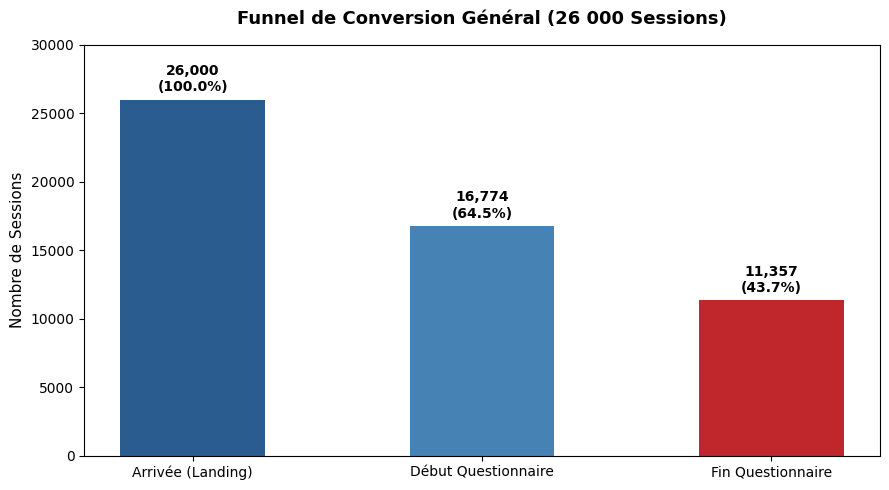

In [33]:
# 1. Graphique du Funnel Général de Conversion
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
steps = ['Arrivée (Landing)', 'Début Questionnaire', 'Fin Questionnaire']
values = [26000, 16774, 11357]
colors = ['#2b5c8f', '#4682b4', '#c0272d']

bars = plt.bar(steps, values, color=colors, width=0.5)
plt.title('Funnel de Conversion Général (26 000 Sessions)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Nombre de Sessions', fontsize=11)

# Afficher les valeurs et pourcentages au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    pct = (yval / 26000) * 100
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 400, f"{yval:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, 30000)
plt.tight_layout()
plt.show()

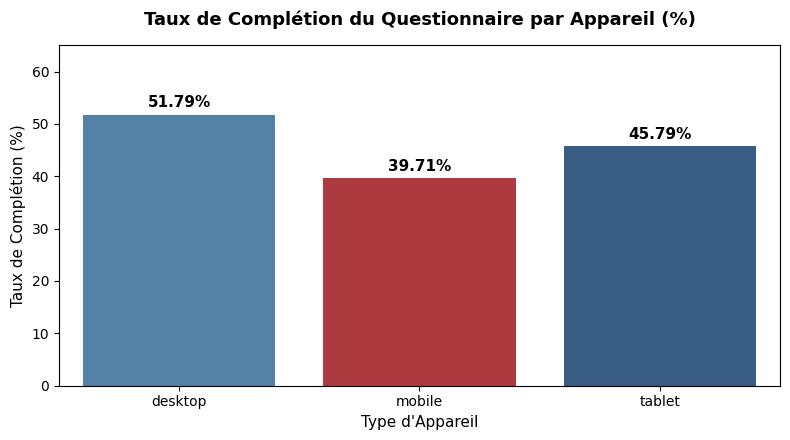

In [41]:
# 2. Graphique de la friction par appareil (Mobile vs Desktop)
device_stats = sessions.groupby('device_type').agg(
    total_sessions=('session_id', 'count'),
    completed_sessions=('completed', 'sum')
).reset_index()

device_stats['taux_completion_pct'] = (device_stats['completed_sessions'] / device_stats['total_sessions'] * 100).round(2)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=device_stats, 
    x='device_type', 
    y='taux_completion_pct', 
    hue='device_type', 
    palette=['#4682b4', '#c0272d', '#2b5c8f'], 
    legend=False
)

plt.title('Taux de Complétion du Questionnaire par Appareil (%)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Taux de Complétion (%)', fontsize=11)
plt.xlabel('Type d\'Appareil', fontsize=11)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

plt.ylim(0, 65)
plt.tight_layout()
plt.show()

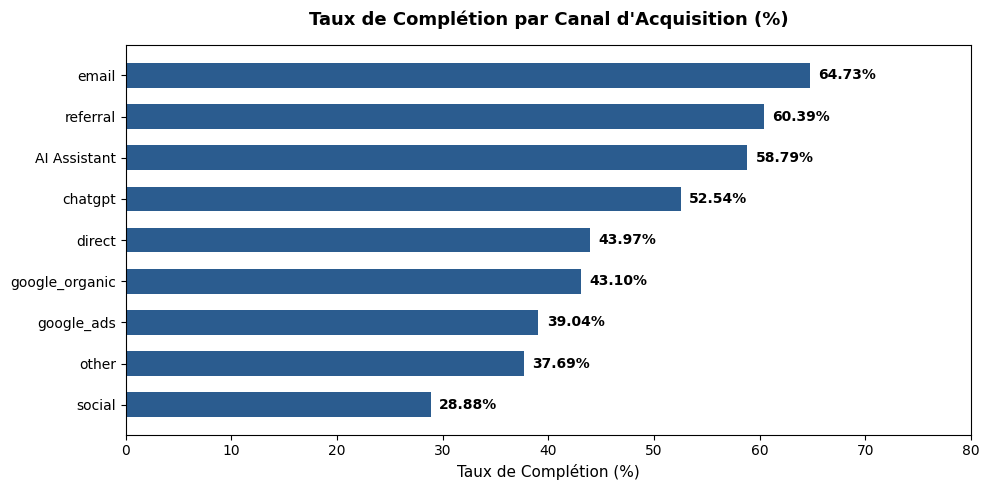

In [36]:
# 3. Graphique comparatif du taux de complétion par Canal d'Acquisition
df_acq_plot = acq.reset_index().sort_values('completion_rate', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_acq_plot['clean_source'], df_acq_plot['completion_rate'], color='#2b5c8f', height=0.6)
plt.title('Taux de Complétion par Canal d\'Acquisition (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Taux de Complétion (%)', fontsize=11)

for index, value in enumerate(df_acq_plot['completion_rate']):
    plt.text(value + 0.8, index, f"{value:.2f}%", va='center', fontweight='bold', fontsize=10)

plt.xlim(0, 80)
plt.tight_layout()
plt.show()

###  Synthèse des Enseignements Graphiques :
1. **Fuite majeure à l'entrée du funnel (-35.5%)** : 26 000 visiteurs arrivent sur la landing page, mais seulement 16 774 cliquent sur "Démarrer". C'est le plus gros levier d'optimisation (taux de rebond immédiat).
2. **Friction Mobile critique (-12.1 pts vs Desktop)** : Le mobile représente **64.5% du trafic global**, mais affiche un taux de complétion de seulement **39.71%** (contre 51.79% sur Desktop). Réduire cette friction mobile apporterait immédiatement plus de 2 000 questionnaires complétés supplémentaires.
3. **Polarisation des Canaux** : L'emailing (64.7%) et les recommandations / referral (60.4%) amènent une audience ultra qualifiée. À l'opposé, les réseaux sociaux ont le taux de complétion le plus faible (28.9%), traduisant un trafic plus passif et volatil.


---
## 7. Analyses & Requêtes SQL Simplifiées 
*Cette section démontre la maîtrise de SQL demandée dans l'énoncé, à l'aide de requêtes claires, directes et facilement défendables en entretien technique.*


In [ ]:
import duckdb

# Initialisation de DuckDB et connexion directe aux DataFrames Pandas
con = duckdb.connect()
con.register("visitors", visitors)
con.register("sessions", sessions)
con.register("events", events)
con.register("answers", answers)
con.register("outcomes", outcomes)

print("Connexion DuckDB prête et tables enregistrées.")


Connexion DuckDB prête et tables enregistrées.


### Requête SQL 1 : Déduplication des réponses 
**Objectif :** Résoudre le problème des multi-clics/réponses multiples en ne conservant que la **dernière réponse chronologique** (`answered_at`) pour chaque question d'une même session.

*Comment ça marche ?*
1. `PARTITION BY session_id, question_number` : regroupe les lignes par session et par question.
2. `ORDER BY answered_at DESC` : trie de la plus récente à la plus ancienne.
3. `ROW_NUMBER() AS rn` : attribue le rang `1` à la dernière réponse.
4. `WHERE rn = 1` : ne retient que la réponse finale.


In [ ]:
query_dedup = """
WITH reponses_triees AS (
    SELECT 
        session_id,
        question_number,
        answer_value,
        answered_at,
        ROW_NUMBER() OVER (
            PARTITION BY session_id, question_number 
            ORDER BY answered_at DESC
        ) AS rn
    FROM answers
)
SELECT 
    question_number,
    COUNT(*) AS total_reponses_propres,
    COUNT(DISTINCT session_id) AS total_sessions
FROM reponses_triees
WHERE rn = 1
GROUP BY question_number
ORDER BY question_number;
"""
df_sql_dedup = con.execute(query_dedup).fetchdf()
display(df_sql_dedup)


question_number  total_reponses_propres  total_sessions
0                1                   15558           15558
1                2                   14779           14779
2                3                   13920           13920
3                4                   12044           12044
4                5                   11462           11462


### Requête SQL 2 : Funnel de Conversion Principal 
**Objectif :** Mesurer les volumes et taux de conversion aux étapes clés du parcours utilisateur sans syntaxe complexe :
- `landing_view` : Arrivée sur la page (26 000)
- `questionnaire_start` : Démarrage du questionnaire (16 774)
- `questionnaire_complete` : Questionnaire terminé (11 357)


In [ ]:
query_funnel_simple = """
SELECT 
    event_type,
    COUNT(DISTINCT session_id) AS nb_sessions,
    ROUND(100.0 * COUNT(DISTINCT session_id) / 26000, 1) AS pct_conversion_globale
FROM events
WHERE event_type IN ('landing_view', 'questionnaire_start', 'questionnaire_complete')
GROUP BY event_type
ORDER BY nb_sessions DESC;
"""
df_sql_funnel = con.execute(query_funnel_simple).fetchdf()
display(df_sql_funnel)


event_type  nb_sessions  pct_conversion_globale
0            landing_view        26000                   100.0
1     questionnaire_start        16774                    64.5
2  questionnaire_complete        11357                    43.7


*Déperdition question par question (Questions 1 à 5) :*


In [ ]:
query_questions_funnel = """
SELECT 
    question_number,
    COUNT(DISTINCT session_id) AS nb_sessions_ayant_vu,
    ROUND(100.0 * COUNT(DISTINCT session_id) / 16774, 1) AS pct_des_demarreurs
FROM events
WHERE event_type = 'question_view'
GROUP BY question_number
ORDER BY question_number;
"""
df_sql_q_funnel = con.execute(query_questions_funnel).fetchdf()
display(df_sql_q_funnel)


question_number  nb_sessions_ayant_vu  pct_des_demarreurs
0                1                 15881                94.7
1                2                 15558                92.7
2                3                 14779                88.1
3                4                 13920                83.0
4                5                 12044                71.8


###  Requête SQL 3 : Performance des Canaux d'Acquisition
**Objectif :** Calculer pour chaque source d'acquisition le volume de trafic et son taux de complétion effectif.


In [ ]:
query_channels = """
SELECT 
    clean_source,
    COUNT(DISTINCT s.session_id) AS total_sessions,
    COUNT(DISTINCT o.session_id) AS questionnaires_completes,
    ROUND(100.0 * COUNT(DISTINCT o.session_id) / COUNT(DISTINCT s.session_id), 1) AS taux_completion_pct
FROM sessions s
LEFT JOIN outcomes o ON s.session_id = o.session_id
GROUP BY clean_source
ORDER BY total_sessions DESC;
"""
df_sql_channels = con.execute(query_channels).fetchdf()
display(df_sql_channels)


clean_source  total_sessions  questionnaires_completes  taux_completion_pct
0  google_organic            7490                      3228                 43.1
1      google_ads            6375                      2489                 39.0
2          social            3618                      1045                 28.9
3         chatgpt            2564                      1347                 52.5
4        referral            1790                      1081                 60.4
5           email            1707                      1105                 64.7
6          direct            1617                       711                 44.0
7           other             674                       254                 37.7
8    AI Assistant             165                        97                 58.8


### Requête SQL 4 : Âge Moyen selon le Résultat Médical
**Objectif :** Vérifier la cohérence épidémiologique en calculant simplement l'**âge moyen** des répondants pour chaque catégorie de résultat santé.

*Requête simple : Jointure directe entre `visitors` et `outcomes`.*


In [ ]:
query_age_moyen = """
SELECT 
    o.outcome_category,
    COUNT(*) AS total_questionnaires,
    ROUND(AVG(2026 - v.birth_year), 1) AS age_moyen,
    MIN(2026 - v.birth_year) AS age_min,
    MAX(2026 - v.birth_year) AS age_max
FROM visitors v
JOIN outcomes o ON v.visitor_id = o.visitor_id
GROUP BY o.outcome_category
ORDER BY age_moyen DESC;
"""
df_sql_age = con.execute(query_age_moyen).fetchdf()
display(df_sql_age)


outcome_category  total_questionnaires  age_moyen  age_min  age_max
0     declared_diagnosed                  1240       50.7       18       96
1          possible_risk                  2276       50.1       16       97
2  no_current_indication                  7841       41.5       16       97


---
**Enseignement clé :**  
Les profils en risque potentiel (`possible_risk`) ou déjà diagnostiqués (`declared_diagnosed`) ont un âge moyen de **50 ans**, soit près de **10 ans de plus** que les profils sains (41.5 ans). Le questionnaire cible donc parfaitement les populations les plus vulnérables.


---
## 8. Réponses Explicites aux 4 Questions Stratégiques du README :

### Quels sont les résultats les plus importants ?

1. **La déperdition majeure se situe sur la Landing Page (35.5% d'abandon immédiat)** :
   * Sur 26 000 sessions, 9 226 utilisateurs quittent la page sans même cliquer sur "Démarrer le questionnaire".
   * Une fois le questionnaire entamé, la rétention moyenne par question est excellente (~95%), à l'exception de la transition vers la Question 5 (chute de **13.5%** entre Q4 et Q5).
     
2. **Une friction mobile critique qui pénalise 65% de l'audience** :
   * Le trafic mobile représente **64.5% des visites (16 772 sessions)** mais affiche un taux de complétion de **39.71%**, contre **51.79% sur Desktop** (un écart massif de **12.1 points**).
   * Aligner l'expérience mobile sur le taux Desktop générerait immédiatement **+2 026 questionnaires complétés**.
     
3. **Le paradoxe des canaux d'acquisition : Volume vs Ciblage Santé** :
   * **L'Emailing (64.7%) et le Referral (60.4%)** sont les canaux les plus engageants, mais attirent une population majoritairement saine (~72% `no_current_indication`).
   * **Google Ads (SEA)** affiche un taux de complétion modéré (39.0%), mais délivre de loin la plus forte concentration de profils à risque : **45.4%** de ses répondants sont en `possible_risk` ou `declared_diagnosed` (contre 23.0% pour le Social). C'est le canal le plus performant pour la mission médicale de Doctoome.
   * **Le canal Social** est sous-performant sur toute la ligne : plus faible complétion (28.9%) et plus faible taux de risque qualifié (23.0%).
     
4. **Validation de la pertinence clinique du modèle de risque** :
   * La prévalence du risque augmente de façon quasi-linéaire avec l'âge (11.0% de risque chez les <35 ans vs **33.7% chez les 65 ans et plus**, et 19.5% déjà diagnostiqués).
   * La Question 1 (diagnostic préalable) et la Question 4 (sédentarité/activité physique) sont les discriminateurs les plus puissants du résultat final.

---

###  Quelles questions restent sans réponse ?

1. **La cause exacte du décrochage à la Question 5** :
   * Pourquoi 13.5% des utilisateurs qui ont déjà répondu à 4 questions abandonnent-ils juste avant la Q5 ? Est-ce lié à la formulation de la question (glycémie / terme médical perçu comme anxiogène), à un temps de chargement, ou à une interface confuse ?
     
2. **Le coût d'acquisition client (CAC) et le ROI financier des campagnes payantes** :
   * Sans les données de dépenses publicitaires (ad spend Google Ads vs Social Ads), impossible de calculer le coût par profil à risque détecté et de statuer sur la rentabilité économique des campagnes.
     
3. **La nature exacte de la friction mobile** :
   * Les abandons mobiles sont-ils dus à une lenteur de chargement (Core Web Vitals), à des boutons non adaptés au tactile (UX/UI), ou à des formulaires mal affichés selon les résolutions d'écran ?
     
4. **L'impact médical réel en aval (Post-questionnaire)** :
   * Que font les 2 276 utilisateurs classés `possible_risk` après avoir vu leur résultat ? Consultent-ils un médecin ? Prennent-ils un rendez-vous sur Doctoome ? Le jeu de données s'arrête à l'événement `questionnaire_complete`.

---

### Quelles données supplémentaires collecteriez-vous ?

1. **Données de télémétrie UX et performance technique** :
   * **Temps passé par étape / par question** (`duration_seconds` entre les événements `question_view` et `question_answer`) pour détecter les questions qui bloquent.
   * **Erreurs JavaScript et temps de chargement** (FCP, LCP) segmentés par navigateur et modèle de smartphone.
   * **Positions de défilement (Scroll depth)** et clics sur les éléments de réassurance de la landing page.
     
2. **Données de conversion post-résultat (Call-to-Action / Funnel aval)** :
   * Clics sur le bouton d'action final (ex: *"Prendre rendez-vous avec un médecin généraliste"* ou *"Trouver un laboratoire de biologie médicale"*).
   * Taux de conversion effectif en prise de rendez-vous sur Doctoome (`booking_id`, `specialty`).
3. **Données marketing et d'attribution enrichies** :
   * Coûts d'acquisition (`cost_per_click`, budget par campagne).
   * Mots-clés de recherche (Google Ads keywords) pour affiner le ciblage d'intention.
     
4. **Consentement et ré-engagement (Opt-in)** :
   * Taux de consentement au suivi email/SMS pour relancer les profils `possible_risk` n'ayant pas consulté.

---

### Que recommanderiez-vous de suivre si le questionnaire restait actif pendant 12 mois ?

1. **Mise en place d'un Dashboard Opérationnel & Alerting automatisé** :
   * **KPIs temps réel** : Taux de rebond Landing, Taux de complétion par canal et par device, Taux de profils à risque détectés.
   * **Alertes de régression** (via Slack/Email) si le taux de complétion d'un device ou canal chute de plus de 15% suite à un déploiement technique.
     
2. **Surveillance du Data Drift (Dérive de données) et de la Saisonnalité** :
   * Monitorer l'évolution de la distribution d'âge et de genre mois par mois (ex. variations pendant les vacances d'été vs rentrée).
   * Suivre la saisonnalité des requêtes santé (pics en novembre lors de la *Journée Mondiale du Diabète*).
     
3. **Programme d'A/B Testing continu** :
   * **Test A/B sur la Landing Page** : Tester un affichage direct de la Question 1 sur la page d'accueil (sans écran de transition) pour neutraliser les 35.5% de rebond.
   * **Test A/B UX Mobile** : Interface type "swipe/cartes" simplifiée pour smartphone afin de combler les 12 points de retard face au Desktop.
     
4. **Monitoring de la Valeur Métier (Santé Publique & Business Doctoome)** :
   * Calculer mensuellement le **coût par patient à risque orienté vers un professionnel de santé** :
     $$\text{Coût par Patient Orienté} = \frac{\text{Budget Marketing Mensuel}}{\text{Nombre de RDV Doctoome générés par des profils à risque}}$$
   * Suivre le taux de revisite à 6 et 12 mois (`is_returning_visitor`) pour mesurer la fidélisation à la plateforme.
